In [10]:
# ====================================================
# CELL 1: Import Libs
# ====================================================
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LSTM,
    Embedding,
    Bidirectional,
    GlobalAveragePooling1D,
    Input,
    LayerNormalization,
    MultiHeadAttention,
    Add,
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print("✅ كل المكتبات تعمل!")

✅ كل المكتبات تعمل!


In [11]:
# ====================================================
# Dataset `IMDB`
# ====================================================
NUM_WORDS = 10000
MAX_LEN = 200

(X_train_seq, y_train), (X_test_seq, y_test) = imdb.load_data(num_words=NUM_WORDS)

# تحويل إلى نص لنموذج TF-IDF
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}


def decode_review(seq):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in seq])


X_train_text = [decode_review(s) for s in X_train_seq]
X_test_text = [decode_review(s) for s in X_test_seq]

# Padding للـ LSTM و Transformer
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post")

print(f"📦 number of train: {len(X_train_seq):,} | number of test: {len(X_test_seq):,}")

📦 number of train: 25,000 | number of test: 25,000


In [12]:
# ====================================================
#  ANN + TF-IDF (Baseline)
# ====================================================
# TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf = tfidf.transform(X_test_text).toarray()

# بناء الشبكة
ann = Sequential(
    [
        Dense(256, activation="relu", input_shape=(5000,)),
        Dropout(0.4),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid"),
    ]
)
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# التدريب
ann_hist = ann.fit(
    X_train_tfidf,
    y_train,
    validation_split=0.15,
    epochs=20,
    batch_size=256,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1,
)

# التقييم
ann_probs = ann.predict(X_test_tfidf).flatten()
ann_preds = (ann_probs > 0.5).astype(int)
print(f"ANN Accuracy: {accuracy_score(y_test, ann_preds):.4f}")
print(f"ANN F1:       {f1_score(y_test, ann_preds):.4f}")
print(f"ANN ROC-AUC:  {roc_auc_score(y_test, ann_probs):.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.7930 - loss: 0.4358 - val_accuracy: 0.8819 - val_loss: 0.2843
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.9131 - loss: 0.2261 - val_accuracy: 0.8800 - val_loss: 0.2920
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9395 - loss: 0.1664 - val_accuracy: 0.8691 - val_loss: 0.3302
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9597 - loss: 0.1184 - val_accuracy: 0.8704 - val_loss: 0.3547
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
ANN Accuracy: 0.8875
ANN F1:       0.8892
ANN ROC-AUC:  0.9552


In [13]:
# ====================================================
# BiLSTM (Intermediate)
# ====================================================
lstm = Sequential(
    [
        Embedding(NUM_WORDS, 64, input_length=MAX_LEN),
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.3)),
        Bidirectional(LSTM(32, dropout=0.3)),
        Dense(64, activation="relu"),
        Dropout(0.4),
        Dense(1, activation="sigmoid"),
    ]
)
lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

lstm_hist = lstm.fit(
    X_train_pad,
    y_train,
    validation_split=0.15,
    epochs=3, # down this for speed resualts
    batch_size=128,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1,
)

lstm_probs = lstm.predict(X_test_pad).flatten()
lstm_preds = (lstm_probs > 0.5).astype(int)
print(f"LSTM Accuracy: {accuracy_score(y_test, lstm_preds):.4f}")

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


167/167 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.6929 - loss: 0.5531 - val_accuracy: 0.8499 - val_loss: 0.3731
Epoch 2/3
167/167 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.8803 - loss: 0.3021 - val_accuracy: 0.8565 - val_loss: 0.3408
Epoch 3/3
167/167 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9213 - loss: 0.2118 - val_accuracy: 0.8664 - val_loss: 0.3291
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 78ms/step
LSTM Accuracy: 0.8685


In [14]:
# ====================================================
# Transformer (Advanced)
# ====================================================
def build_transformer(vocab_size, max_len):
    inputs = Input(shape=(max_len,))
    x = Embedding(vocab_size, 64)(inputs)

    # Transformer Block
    attn = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    ff = Dense(128, activation="relu")(x)
    ff = Dense(64)(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


transformer = build_transformer(NUM_WORDS, MAX_LEN)

trans_hist = transformer.fit(
    X_train_pad,
    y_train,
    validation_split=0.15,
    epochs=3,# train with only 3
    batch_size=128,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1,
)

trans_probs = transformer.predict(X_test_pad).flatten()
trans_preds = (trans_probs > 0.5).astype(int)
print(f"Transformer Accuracy: {accuracy_score(y_test, trans_preds):.4f}")

Epoch 1/3
167/167 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.7482 - loss: 0.4807 - val_accuracy: 0.8083 - val_loss: 0.4550
Epoch 2/3
167/167 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.9021 - loss: 0.2462 - val_accuracy: 0.8816 - val_loss: 0.2949
Epoch 3/3
167/167 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.9357 - loss: 0.1721 - val_accuracy: 0.8755 - val_loss: 0.3231
782/782 ━━━━━━━━━━━━━━━━━━━━ 105s 134ms/step
Transformer Accuracy: 0.8746


    النموذج        النوع  Accuracy  F1-Score  ROC-AUC
 ANN+TF-IDF     Baseline    0.8875    0.8892   0.9552
     BiLSTM Intermediate    0.8685    0.8725   0.9413
Transformer     Advanced    0.8746    0.8751   0.9478


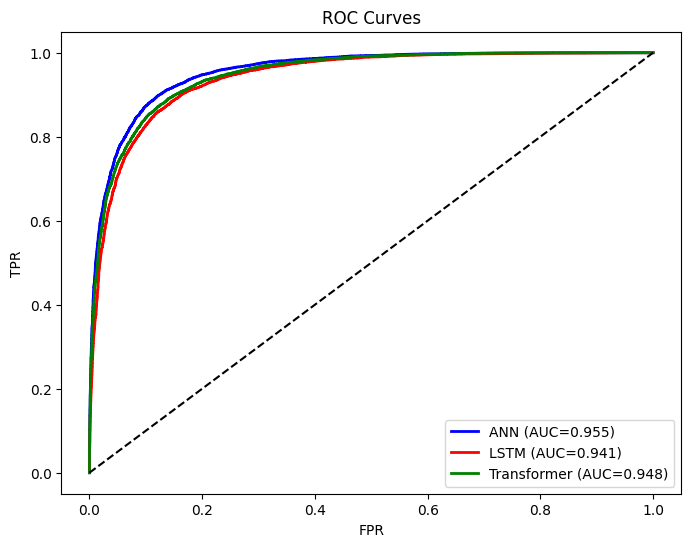

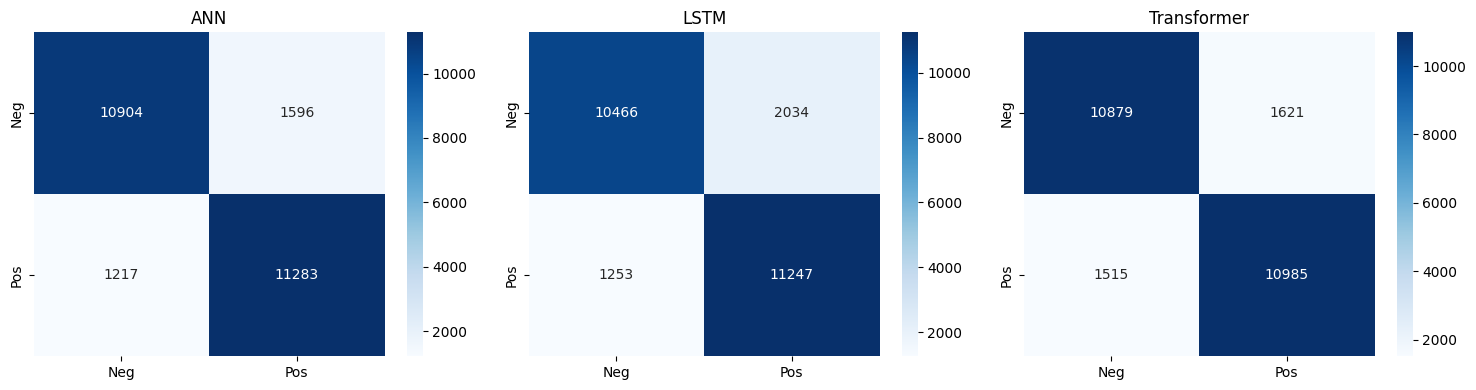

In [15]:
# ====================================================
# Compare between the models
# ====================================================
# جدول المقارنة
results = pd.DataFrame(
    {
        "النموذج": ["ANN+TF-IDF", "BiLSTM", "Transformer"],
        "النوع": ["Baseline", "Intermediate", "Advanced"],
        "Accuracy": [
            accuracy_score(y_test, ann_preds),
            accuracy_score(y_test, lstm_preds),
            accuracy_score(y_test, trans_preds),
        ],
        "F1-Score": [
            f1_score(y_test, ann_preds),
            f1_score(y_test, lstm_preds),
            f1_score(y_test, trans_preds),
        ],
        "ROC-AUC": [
            roc_auc_score(y_test, ann_probs),
            roc_auc_score(y_test, lstm_probs),
            roc_auc_score(y_test, trans_probs),
        ],
    }
)
print(results.round(4).to_string(index=False))

# رسم ROC
plt.figure(figsize=(8, 6))
for name, probs, color in [
    ("ANN", ann_probs, "blue"),
    ("LSTM", lstm_probs, "red"),
    ("Transformer", trans_probs, "green"),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2, color=color)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves")
plt.legend()
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name, preds in zip(
    axes, ["ANN", "LSTM", "Transformer"], [ann_preds, lstm_preds, trans_preds]
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Neg", "Pos"],
        yticklabels=["Neg", "Pos"],
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

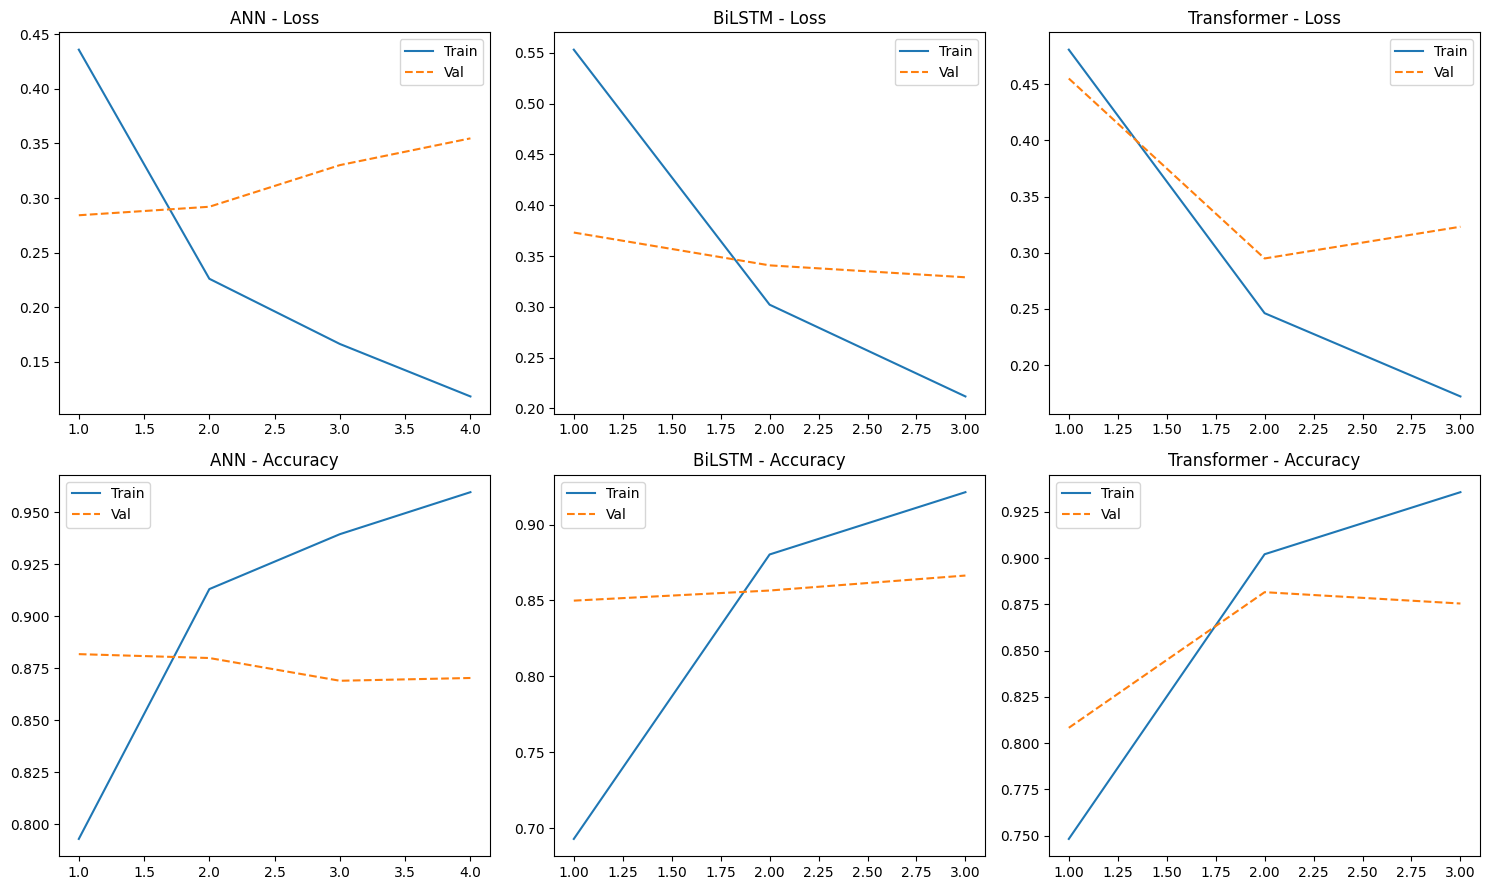

In [16]:
# ====================================================
# CELL 7: منحنيات التعلم
# ====================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
histories = [ann_hist, lstm_hist, trans_hist]
names = ["ANN", "BiLSTM", "Transformer"]

for col, (hist, name) in enumerate(zip(histories, names)):
    ep = range(1, len(hist.history["loss"]) + 1)
    axes[0, col].plot(ep, hist.history["loss"], label="Train")
    axes[0, col].plot(ep, hist.history["val_loss"], label="Val", linestyle="--")
    axes[0, col].set_title(f"{name} - Loss")
    axes[0, col].legend()

    axes[1, col].plot(ep, hist.history["accuracy"], label="Train")
    axes[1, col].plot(ep, hist.history["val_accuracy"], label="Val", linestyle="--")
    axes[1, col].set_title(f"{name} - Accuracy")
    axes[1, col].legend()

plt.tight_layout()
plt.show()

In [17]:
# LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

# ── 1. بناء الـ Tokenizer ──
MAX_LEN   = 200
NUM_WORDS = 10000

tokenizer_lstm = Tokenizer(num_words=NUM_WORDS)
tokenizer_lstm.fit_on_texts(X_train_text)  # X_train_text موجود من قبل

X_train_seq = tokenizer_lstm.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer_lstm.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post')

print(f"✅ X_train_pad shape: {X_train_pad.shape}")
print(f"✅ X_test_pad shape:  {X_test_pad.shape}")

# ── 2. بناء النموذج ──
lstm_model = Sequential([
    Embedding(NUM_WORDS, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.3)),
    Bidirectional(LSTM(32, dropout=0.3)),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
], name="BiLSTM")

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

✅ X_train_pad shape: (25000, 200)
✅ X_test_pad shape:  (25000, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train LSTM
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.15,
    epochs=3,# take only 3 Epochs
    batch_size=128,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/3
167/167 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.7465 - loss: 0.4937 - val_accuracy: 0.8251 - val_loss: 0.4003
Epoch 2/3
167/167 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.8984 - loss: 0.2685 - val_accuracy: 0.8787 - val_loss: 0.3415
Epoch 3/3
167/167 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.9338 - loss: 0.1861 - val_accuracy: 0.8744 - val_loss: 0.3602


782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 90ms/step
📊 نتائج BiLSTM:
   Accuracy : 0.8728
   F1-Score : 0.8729
   ROC-AUC  : 0.9421


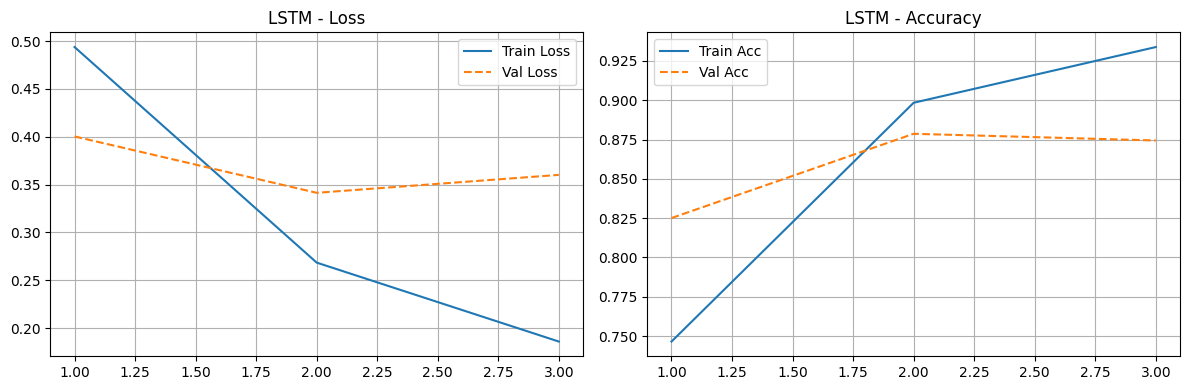

In [19]:
# Rate LSTM
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

lstm_probs = lstm_model.predict(X_test_pad).flatten()
lstm_preds = (lstm_probs > 0.5).astype(int)

print("=" * 40)
print("📊 نتائج BiLSTM:")
print(f"   Accuracy : {accuracy_score(y_test, lstm_preds):.4f}")
print(f"   F1-Score : {f1_score(y_test, lstm_preds):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_test, lstm_probs):.4f}")
print("=" * 40)

# رسم منحنيات التعلم
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(lstm_history.history['loss']) + 1)

axes[0].plot(epochs, lstm_history.history['loss'],     label='Train Loss')
axes[0].plot(epochs, lstm_history.history['val_loss'], label='Val Loss', linestyle='--')
axes[0].set_title('LSTM - Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, lstm_history.history['accuracy'],     label='Train Acc')
axes[1].plot(epochs, lstm_history.history['val_accuracy'], label='Val Acc', linestyle='--')
axes[1].set_title('LSTM - Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

In [20]:
# update the libs before
!pip install -q transformers tensorflow -U

In [ ]:
# BERT
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
import tensorflow as tf

# ── 1. تحميل الـ Tokenizer ──
print("📦 تحميل DistilBERT Tokenizer...")
bert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# ── 2. تحويل البيانات ──
# نأخذ عينة أصغر لتسريع التدريب في Colab
SAMPLE = 5000
MAX_LEN_BERT = 128

X_train_sample = X_train_text[:SAMPLE]
y_train_sample = y_train[:SAMPLE]
X_test_sample  = X_test_text[:1000]
y_test_sample  = y_test[:1000]

def encode_texts(texts, tokenizer, max_len):
    return tokenizer(
        texts,
        max_length=max_len,
        truncation=True,
        padding='max_length',
        return_tensors='tf'
    )

print("🔄 تحويل بيانات التدريب...")
train_encodings = encode_texts(X_train_sample, bert_tokenizer, MAX_LEN_BERT)

print("🔄 تحويل بيانات الاختبار...")
test_encodings  = encode_texts(X_test_sample,  bert_tokenizer, MAX_LEN_BERT)

# ── 3. بناء الـ Dataset ──
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train_sample
)).shuffle(1000).batch(16)

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    y_test_sample
)).batch(16)

print("✅ البيانات جاهزة!")

ImportError: cannot import name 'TFDistilBertForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [ ]:
# Train BERT
print("📦 تحميل DistilBERT Model...")
bert_model = TFDistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

bert_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("🚀 تدريب BERT (هذا يأخذ وقتاً أطول)...")
bert_history = bert_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=3,   # 3 كافية لـ BERT
    verbose=1
)

In [ ]:
# Rate BERT
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# استخراج التوقعات
outputs    = bert_model.predict(test_dataset)
bert_probs = tf.nn.softmax(outputs.logits, axis=1).numpy()[:, 1]
bert_preds = (bert_probs > 0.5).astype(int)

print("=" * 40)
print("📊 نتائج DistilBERT:")
print(f"   Accuracy : {accuracy_score(y_test_sample, bert_preds):.4f}")
print(f"   F1-Score : {f1_score(y_test_sample, bert_preds):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_test_sample, bert_probs):.4f}")
print("=" * 40)

In [ ]:
# Final Compare
import pandas as pd

results = pd.DataFrame({
    'النموذج'  : ['ANN + TF-IDF', 'BiLSTM', 'DistilBERT'],
    'النوع'    : ['Baseline', 'Intermediate', 'Advanced'],
    'Accuracy' : [
        accuracy_score(y_test, ann_preds),
        accuracy_score(y_test, lstm_preds),
        accuracy_score(y_test_sample, bert_preds)
    ],
    'F1-Score' : [
        f1_score(y_test, ann_preds),
        f1_score(y_test, lstm_preds),
        f1_score(y_test_sample, bert_preds)
    ],
    'ROC-AUC'  : [
        roc_auc_score(y_test, ann_probs),
        roc_auc_score(y_test, lstm_probs),
        roc_auc_score(y_test_sample, bert_probs)
    ]
})

print(results.round(4).to_string(index=False))

# رسم المقارنة
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
colors  = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics):
    bars = axes[idx].bar(results['النموذج'], results[metric],
                          color=colors, edgecolor='white')
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    axes[idx].set_ylim(0.7, 1.0)
    for bar, val in zip(bars, results[metric]):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 0.003,
                       f'{val:.4f}', ha='center', fontsize=9)

plt.suptitle("مقارنة النماذج الثلاثة", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# save as ANN  
# import pickle
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences

# # ── 1. احفظ الـ Tokenizer ──
# tokenizer = Tokenizer(num_words=10000)
# tokenizer.fit_on_texts(X_train_text)

# with open('tokenizer.pkl', 'wb') as f:
#     pickle.dump(tokenizer, f)

# # ── 2. احفظ النموذج الصحيح ──
# transformer.save('best_model.h5')   

# # ── 3. حمّل الملفين ──
# from google.colab import files
# files.download('tokenizer.pkl')
# files.download('best_model.h5')

# save as LSTM
lstm_model.save('best_model.h5')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer_lstm, f)

from google.colab import files
files.download('best_model.h5')
files.download('tokenizer.pkl')


print("✅ تم الحفظ والتحميل!")

# save as BERT

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ تم الحفظ والتحميل!
